# Mundial 2026 — Notebook de MODELO

Construye las features, entrena los modelos y genera predicciones visuales.

**Este notebook no hace ninguna petición de red.** Todo lo que necesita ya lo
dejó preparado `mundial2026_datos.ipynb` en `data/`:

- `world_cup_matches.csv` — partidos del Mundial
- `pre_world_cup_form.csv` — forma pre-Mundial ponderada
- `bracket_structure.json` — estructura del cuadro de eliminatorias
- `teams.csv` — Elo, ranking FIFA y grupo (snapshot local; así no hace falta `kagglehub` aquí)

Si `data/` está desactualizado, vuelve a ejecutar el notebook de datos primero.

**Dependencias:** `pip install pandas xgboost scikit-learn matplotlib`


## 1. Carga de datos (sin red)

In [1]:
import json
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data")

wc = pd.read_csv(DATA_DIR / "world_cup_matches.csv")
form = pd.read_csv(DATA_DIR / "pre_world_cup_form.csv")
teams = pd.read_csv(DATA_DIR / "teams.csv")
bracket_structure = json.load(open(DATA_DIR / "bracket_structure.json", encoding="utf-8"))
GROUPS = bracket_structure["groups"]

print(f"world_cup_matches.csv : {len(wc)} filas ({(wc.status == 'played').sum()} jugados)")
print(f"pre_world_cup_form.csv: {len(form)} filas ({form.team.nunique()} selecciones)")
print(f"teams.csv             : {len(teams)} selecciones")
print(f"bracket_structure.json: {len(bracket_structure['round_of_32'])} partidos de dieciseisavos")

world_cup_matches.csv : 94 filas (88 jugados)
pre_world_cup_form.csv: 240 filas (48 selecciones)
teams.csv             : 48 selecciones
bracket_structure.json: 16 partidos de dieciseisavos


## 2. `get_bracket_state()` (duplicado local, sin red)

Mismas funciones que en `mundial2026_datos.ipynb` — se duplican aquí a propósito
para que este notebook siga siendo autocontenido y no dependa de ejecutar el
otro primero en la misma sesión. Solo leen `wc` y `bracket_structure`, ya en memoria.

In [2]:
def compute_group_standings(wc_df):
    gs = wc_df[(wc_df["round"] == "Group stage") & (wc_df["status"] == "played")]
    rows = []
    for _, r in gs.iterrows():
        rows.append((r.home_team, r.home_goals, r.away_goals))
        rows.append((r.away_team, r.away_goals, r.home_goals))
    tbl = pd.DataFrame(rows, columns=["team", "gf", "ga"])
    tbl["pts"] = tbl.apply(lambda x: 3 if x.gf > x.ga else (1 if x.gf == x.ga else 0), axis=1)
    agg = tbl.groupby("team").agg(gf=("gf", "sum"), ga=("ga", "sum"),
                                  played=("gf", "size"), pts=("pts", "sum")).reset_index()
    agg["gd"] = agg.gf - agg.ga
    team2group = {t: g for g, teams_ in GROUPS.items() for t in teams_}
    agg["group"] = agg["team"].map(team2group)
    agg = agg.sort_values(["group", "pts", "gd", "gf"], ascending=[True, False, False, False])
    agg["position"] = agg.groupby("group").cumcount() + 1
    agg["group_complete"] = agg.groupby("group")["played"].transform(lambda s: (s == 3).all())
    return agg.reset_index(drop=True)


def rank_third_place(standings):
    thirds = standings[(standings.position == 3) & standings.group_complete].copy()
    thirds = thirds.sort_values(["pts", "gd", "gf"], ascending=[False, False, False]).reset_index(drop=True)
    thirds["third_rank"] = thirds.index + 1
    return thirds


def resolve_group_slot(slot, standings):
    pos, group = int(slot[0]), slot[1]
    g = standings[standings.group == group]
    if g.empty or not g["group_complete"].iloc[0]:
        return None
    row = g[g.position == pos]
    return row.iloc[0].team if len(row) else None


def resolve_third_slot(group, standings, qualified_thirds):
    if group not in qualified_thirds:
        return None
    g = standings[(standings.group == group) & (standings.position == 3)]
    if g.empty or not g["group_complete"].iloc[0]:
        return None
    return g.iloc[0].team


def _resolve_slot(slot, standings, qualified_thirds):
    return (resolve_group_slot(slot, standings) if slot[0] in "12"
            else resolve_third_slot(slot[1], standings, qualified_thirds))


def _resolve_source(src, rows_by_num):
    kind, num = src[0], int(src[1:])
    feeder = rows_by_num.get(num)
    if not feeder or not feeder["winner"]:
        return None
    return feeder["winner"] if kind == "W" else feeder["loser"]


def _describe_source(src, rows_by_num):
    kind, num = src[0], int(src[1:])
    label = "Ganador" if kind == "W" else "Perdedor"
    feeder = rows_by_num.get(num)
    if feeder and feeder["confirmed_teams"]:
        return f"{label} de Partido {num} ({feeder['home_team']} vs {feeder['away_team']})"
    return f"{label} de Partido {num}"


def _find_match_row(wc_df, round_name, home, away):
    cand = wc_df[(wc_df["round"] == round_name) &
                (((wc_df.home_team == home) & (wc_df.away_team == away)) |
                 ((wc_df.home_team == away) & (wc_df.away_team == home)))]
    return cand.iloc[0] if len(cand) else None


def _find_conflicts(wc_df, round_name, home, away):
    involved = wc_df[(wc_df["round"] == round_name) &
                     (wc_df.home_team.isin([home, away]) | wc_df.away_team.isin([home, away]))]
    return [f"{r.home_team} vs {r.away_team} ({r.status})" for _, r in involved.iterrows()
            if {r.home_team, r.away_team} != {home, away}]


def _settle_match(wc_df, match_number, round_name, home_slot, away_slot, home, away, rows_by_num):
    row = {"match_number": match_number, "round": round_name,
           "home_slot": home_slot, "away_slot": away_slot,
           "winner": None, "loser": None}
    if home is None or away is None:
        row["home_team"] = home or _describe_source(home_slot, rows_by_num)
        row["away_team"] = away or _describe_source(away_slot, rows_by_num)
        row["confirmed_teams"] = False
        row["status"] = "condicional"
        row["result"] = None
        row["confirmed_by_data"] = False
        row["discrepancy"] = None
        rows_by_num[match_number] = row
        return row
    row["home_team"], row["away_team"], row["confirmed_teams"] = home, away, True
    match_row = _find_match_row(wc_df, round_name, home, away)
    conflicts = _find_conflicts(wc_df, round_name, home, away)
    row["discrepancy"] = ("El CSV tiene en esta ronda otra fila con uno de estos equipos pero "
                          f"rival distinto: {'; '.join(conflicts)}") if conflicts else None
    if match_row is None:
        row["status"], row["result"], row["confirmed_by_data"] = "pendiente (sin fila en el CSV)", None, False
    elif match_row["status"] != "played":
        row["status"], row["result"], row["confirmed_by_data"] = "scheduled", None, True
    else:
        row["confirmed_by_data"] = True
        if match_row.home_team == home:
            h_g, a_g = match_row.home_goals, match_row.away_goals
            h_p, a_p = match_row.get("home_pens"), match_row.get("away_pens")
        else:
            h_g, a_g = match_row.away_goals, match_row.home_goals
            h_p, a_p = match_row.get("away_pens"), match_row.get("home_pens")
        if h_g > a_g:
            row["winner"], row["loser"] = home, away
        elif a_g > h_g:
            row["winner"], row["loser"] = away, home
        elif pd.notna(h_p) and pd.notna(a_p):
            row["winner"], row["loser"] = (home, away) if h_p > a_p else (away, home)
        row["status"] = "played"
        row["result"] = f"{h_g:.0f}-{a_g:.0f}" + (f" (pen. {h_p:.0f}-{a_p:.0f})" if pd.notna(h_p) else "")
    rows_by_num[match_number] = row
    return row


def get_bracket_state(wc_df=None, bracket=None):
    wc_df = wc if wc_df is None else wc_df
    bracket = bracket_structure if bracket is None else bracket
    standings = compute_group_standings(wc_df)
    thirds_ranked = rank_third_place(standings)
    qualified_thirds = (set(thirds_ranked.head(8).group) if len(thirds_ranked) >= 8
                        else set(bracket["qualified_third_place_groups_2026"]))
    rows_by_num = {}
    for m in bracket["round_of_32"]:
        home = _resolve_slot(m["home_slot"], standings, qualified_thirds)
        away = _resolve_slot(m["away_slot"], standings, qualified_thirds)
        _settle_match(wc_df, m["match_number"], "Round of 32",
                     m["home_slot"], m["away_slot"], home, away, rows_by_num)
    for m in bracket["progression"]:
        home = _resolve_source(m["home_source"], rows_by_num)
        away = _resolve_source(m["away_source"], rows_by_num)
        _settle_match(wc_df, m["match_number"], m["round"],
                     m["home_source"], m["away_source"], home, away, rows_by_num)
    cols = ["match_number", "round", "home_team", "away_team", "confirmed_teams",
           "status", "result", "confirmed_by_data", "discrepancy"]
    return pd.DataFrame(rows_by_num.values())[cols].sort_values("match_number").reset_index(drop=True)


bracket_state = get_bracket_state(wc)
print(f"Casillas: {len(bracket_state)} | confirmadas: {int(bracket_state.confirmed_teams.sum())} "
      f"| condicionales: {int((~bracket_state.confirmed_teams).sum())}")

Casillas: 32 | confirmadas: 24 | condicionales: 8


## 3. Dataset de entrenamiento — `data/features.csv`

Una fila por partido **ya jugado** del Mundial, con features conocidas *antes*
del pitido inicial (nada de posesión/tiros/xG del propio partido — sería fuga
de información):

- **Elo y ranking FIFA** (`teams.csv`) y su diferencia `elo_diff`.
- **Forma pre-Mundial ponderada** (`pre_world_cup_form.csv`) por `competition_weight`.
- **Forma EN el torneo** (`*_t_*`): medias de los partidos *anteriores* del
  propio Mundial de cada selección — xG a favor/en contra, posesión y tiros a
  puerta a favor/en contra. Usar los stats de partidos ya disputados **no** es
  fuga de información (se conocen antes del pitido); lo prohibido es usar los
  del propio partido. En el primer partido de cada selección no existen (NaN);
  XGBoost trata los NaN de forma nativa.
- **Fase** (`phase_ordinal`): 0 = grupos, 1 = dieciseisavos... hasta 6 = final.
- **Descanso**: días desde el partido anterior de cada selección en el propio
  Mundial (el primero de cada selección se imputa con la mediana del resto).

In [3]:
import numpy as np

ROUND_ORDER = ["Group stage", "Round of 32", "Round of 16", "Quarterfinal",
              "Semifinal", "Third place", "Final"]
ROUND_ORDINAL = {r: i for i, r in enumerate(ROUND_ORDER)}

TEAMS_INFO = teams.set_index("team_name")[["elo_rating", "fifa_ranking_pre_tournament"]].to_dict("index")


def team_strength(team):
    """Elo y ranking FIFA pre-Mundial de una selección (snapshot fijo)."""
    info = TEAMS_INFO.get(team)
    if info is None:
        return {"elo": None, "fifa_rank": None}
    return {"elo": float(info["elo_rating"]), "fifa_rank": float(info["fifa_ranking_pre_tournament"])}


def team_pre_wc_form(team, form_df=None, n=5):
    """Forma pre-Mundial ponderada por competition_weight: goles a favor/en contra y % victorias."""
    form_df = form if form_df is None else form_df
    g = form_df[form_df.team == team].sort_values("match_date").tail(n)
    if g.empty:
        return {"form_gf": None, "form_ga": None, "form_winrate": None}
    w = g.competition_weight
    win = (g.result == "W").astype(float)
    return {
        "form_gf": (g.goals_for * w).sum() / w.sum(),
        "form_ga": (g.goals_against * w).sum() / w.sum(),
        "form_winrate": (win * w).sum() / w.sum(),
    }


def team_rest_days(team, before_date, wc_df):
    """Días desde el partido anterior de esa selección EN EL MUNDIAL (None si es el primero)."""
    prev = wc_df[(wc_df.status == "played") &
                ((wc_df.home_team == team) | (wc_df.away_team == team)) &
                (pd.to_datetime(wc_df.date) < pd.to_datetime(before_date))]
    if prev.empty:
        return None
    return (pd.to_datetime(before_date) - pd.to_datetime(prev.date).max()).days


def team_tournament_stats(team, before_date, wc_df):
    """Forma EN el torneo: medias de los partidos del Mundial de la selección
    anteriores a `before_date` — xG a favor/en contra, posesión y tiros a
    puerta a favor/en contra. None (NaN) si aún no ha jugado ninguno."""
    prev = wc_df[(wc_df.status == "played") &
                ((wc_df.home_team == team) | (wc_df.away_team == team)) &
                (pd.to_datetime(wc_df.date) < pd.to_datetime(before_date))]
    if prev.empty:
        return {"t_xg_for": None, "t_xg_against": None, "t_poss": None,
                "t_sot_for": None, "t_sot_against": None}
    xg_f, xg_a, poss, sot_f, sot_a = [], [], [], [], []
    for _, r in prev.iterrows():
        us, them = ("home", "away") if r.home_team == team else ("away", "home")
        if pd.notna(r[f"{us}_xg"]):
            xg_f.append(r[f"{us}_xg"]); xg_a.append(r[f"{them}_xg"])
        if pd.notna(r[f"{us}_possession"]):
            poss.append(r[f"{us}_possession"])
        if pd.notna(r[f"{us}_shots_on_target"]):
            sot_f.append(r[f"{us}_shots_on_target"]); sot_a.append(r[f"{them}_shots_on_target"])
    mean = lambda v: float(np.mean(v)) if v else None
    return {"t_xg_for": mean(xg_f), "t_xg_against": mean(xg_a), "t_poss": mean(poss),
            "t_sot_for": mean(sot_f), "t_sot_against": mean(sot_a)}


def build_features(wc_df):
    played = wc_df[wc_df.status == "played"].sort_values("date").reset_index(drop=True)
    rows = []
    for _, m in played.iterrows():
        home, away = m.home_team, m.away_team
        h_str, a_str = team_strength(home), team_strength(away)
        h_form, a_form = team_pre_wc_form(home), team_pre_wc_form(away)
        h_rest = team_rest_days(home, m.date, wc_df)
        a_rest = team_rest_days(away, m.date, wc_df)
        h_t = team_tournament_stats(home, m.date, wc_df)
        a_t = team_tournament_stats(away, m.date, wc_df)
        rows.append({
            "match_id": m.match_id, "date": m.date, "round": m["round"],
            "phase_ordinal": ROUND_ORDINAL.get(m["round"]),
            "home_team": home, "away_team": away,
            "home_elo": h_str["elo"], "away_elo": a_str["elo"],
            "elo_diff": (h_str["elo"] - a_str["elo"]) if None not in (h_str["elo"], a_str["elo"]) else None,
            "home_fifa_rank": h_str["fifa_rank"], "away_fifa_rank": a_str["fifa_rank"],
            "home_form_gf": h_form["form_gf"], "home_form_ga": h_form["form_ga"],
            "home_form_winrate": h_form["form_winrate"],
            "away_form_gf": a_form["form_gf"], "away_form_ga": a_form["form_ga"],
            "away_form_winrate": a_form["form_winrate"],
            "home_rest_days": h_rest, "away_rest_days": a_rest,
            **{f"home_{k}": v for k, v in h_t.items()},
            **{f"away_{k}": v for k, v in a_t.items()},
            "competition_weight": m.competition_weight,
            "home_goals": m.home_goals, "away_goals": m.away_goals,
        })
    df = pd.DataFrame(rows)
    median_rest = pd.concat([df.home_rest_days, df.away_rest_days]).median()
    df["home_rest_days"] = df.home_rest_days.fillna(median_rest)
    df["away_rest_days"] = df.away_rest_days.fillna(median_rest)
    return df


features = build_features(wc)
features.to_csv(DATA_DIR / "features.csv", index=False)
print(f"Guardado data/features.csv: {len(features)} partidos jugados x {features.shape[1]} columnas")
print("Rondas presentes en el training set:", features["round"].value_counts().to_dict())
print(f"Sin forma en-torneo (primer partido de la selección): "
      f"{int(features.home_t_xg_for.isna().sum())} filas local / "
      f"{int(features.away_t_xg_for.isna().sum())} filas visitante (NaN, XGBoost los maneja)")

Guardado data/features.csv: 88 partidos jugados x 32 columnas
Rondas presentes en el training set: {'Group stage': 72, 'Round of 32': 16}
Sin forma en-torneo (primer partido de la selección): 24 filas local / 24 filas visitante (NaN, XGBoost los maneja)


## 4. Modelo: XGBoost doble con forma en-torneo (xG, posesión, tiros a puerta)

> **Decisión basada en los datos actuales, a revisar más adelante.**
> Con los 88 partidos disponibles a 4-jul-2026 (70 en train, 18 en test — 16
> dieciseisavos + 2 grupos), split temporal 80/20, MAE test **promediado sobre
> 5 seeds** de XGBoost:
>
> | Modelo goles LOCAL | MAE test |
> |---|---|
> | Baseline (media del train) | 0.770 |
> | Poisson simple (elo+fase) — producción anterior | 0.751 |
> | XGBoost 14 features (sin forma en-torneo) | 0.806 |
> | **XGBoost 24 features (+xG/posesión/tiros en-torneo)** | **0.752** |
>
> | Modelo goles VISITANTE | MAE test |
> |---|---|
> | Baseline (media del train) | 0.786 |
> | Poisson simple (elo+fase) | 0.724 |
> | XGBoost 14 features — producción anterior | 0.636 |
> | **XGBoost 24 features (+xG/posesión/tiros en-torneo)** | **0.639** |
>
> **Qué cambió respecto al esquema híbrido anterior** (Poisson local + XGBoost
> visitante): la forma en-torneo cierra por completo el gap del XGBoost local
> (0.806 → 0.752, empate técnico con Poisson) y empata en el visitante. Se
> adopta **XGBoost con las 24 features en ambos lados** porque, a igualdad de
> MAE hoy, da acceso a señal que el Poisson simple no ve: el Elo es un snapshot
> pre-torneo estático, mientras que xG/posesión/tiros en-torneo capturan la
> forma real de cada selección según avanza el Mundial — justo lo que importa
> en las rondas eliminatorias que quedan por predecir.
> **Repetir esta comparación** cuando se jueguen octavos y cuartos.

In [4]:
from xgboost import XGBRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

TOURN_COLS = [f"{side}_t_{k}" for side in ("home", "away")
              for k in ("xg_for", "xg_against", "poss", "sot_for", "sot_against")]
FEATURE_COLS = ["home_elo", "away_elo", "elo_diff", "home_fifa_rank", "away_fifa_rank",
               "home_form_gf", "home_form_ga", "home_form_winrate",
               "away_form_gf", "away_form_ga", "away_form_winrate",
               "home_rest_days", "away_rest_days", "phase_ordinal"] + TOURN_COLS
SIMPLE_COLS = ["elo_diff", "phase_ordinal"]  # solo para la comparación con Poisson

feat_sorted = features.sort_values("date").reset_index(drop=True)
split = int(len(feat_sorted) * 0.8)
train, test = feat_sorted.iloc[:split].copy(), feat_sorted.iloc[split:].copy()
print(f"Train: {len(train)} partidos ({train.date.min()} -> {train.date.max()})")
print(f"Test : {len(test)} partidos ({test.date.min()} -> {test.date.max()})")


def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def _make_xgb():
    return XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        reg_lambda=5.0, min_child_weight=3, random_state=42)


# --- LOCAL y VISITANTE: XGBoost con las 24 features (ganador de la comparación) ---
model_home = _make_xgb()
model_home.fit(train[FEATURE_COLS], train["home_goals"],
               sample_weight=train.competition_weight)
model_away = _make_xgb()
model_away.fit(train[FEATURE_COLS], train["away_goals"],
               sample_weight=train.competition_weight)

# Referencia: el Poisson simple que era producción para el local
_pois_ref = PoissonRegressor(alpha=1.0, max_iter=500)
_pois_ref.fit(train[SIMPLE_COLS], train["home_goals"])

print()
print(pd.DataFrame([
    {"modelo": "XGBoost 24f (local, PRODUCCIÓN)",
     "MAE train": mean_absolute_error(train.home_goals, model_home.predict(train[FEATURE_COLS])),
     "MAE test": mean_absolute_error(test.home_goals, model_home.predict(test[FEATURE_COLS])),
     "RMSE test": rmse(test.home_goals, model_home.predict(test[FEATURE_COLS]))},
    {"modelo": "Poisson simple (local, referencia)",
     "MAE train": mean_absolute_error(train.home_goals, _pois_ref.predict(train[SIMPLE_COLS])),
     "MAE test": mean_absolute_error(test.home_goals, _pois_ref.predict(test[SIMPLE_COLS])),
     "RMSE test": rmse(test.home_goals, _pois_ref.predict(test[SIMPLE_COLS]))},
    {"modelo": "XGBoost 24f (visitante, PRODUCCIÓN)",
     "MAE train": mean_absolute_error(train.away_goals, model_away.predict(train[FEATURE_COLS])),
     "MAE test": mean_absolute_error(test.away_goals, model_away.predict(test[FEATURE_COLS])),
     "RMSE test": rmse(test.away_goals, model_away.predict(test[FEATURE_COLS]))},
]).round(3).to_string(index=False))

Train: 70 partidos (2026-06-11 -> 2026-06-27)
Test : 18 partidos (2026-06-27 -> 2026-07-03)



                             modelo  MAE train  MAE test  RMSE test
    XGBoost 24f (local, PRODUCCIÓN)      0.553     0.755      1.027
 Poisson simple (local, referencia)      1.102     0.751      0.890
XGBoost 24f (visitante, PRODUCCIÓN)      0.356     0.649      0.871


### Importancia de features (XGBoost, ambos lados)

Gain relativo de cada feature en los dos modelos. Las features `*_t_*` son la
forma en-torneo (xG a favor/en contra, posesión, tiros a puerta) añadida en
esta versión — comprobar cuánto peso les asigna el modelo frente al Elo estático.

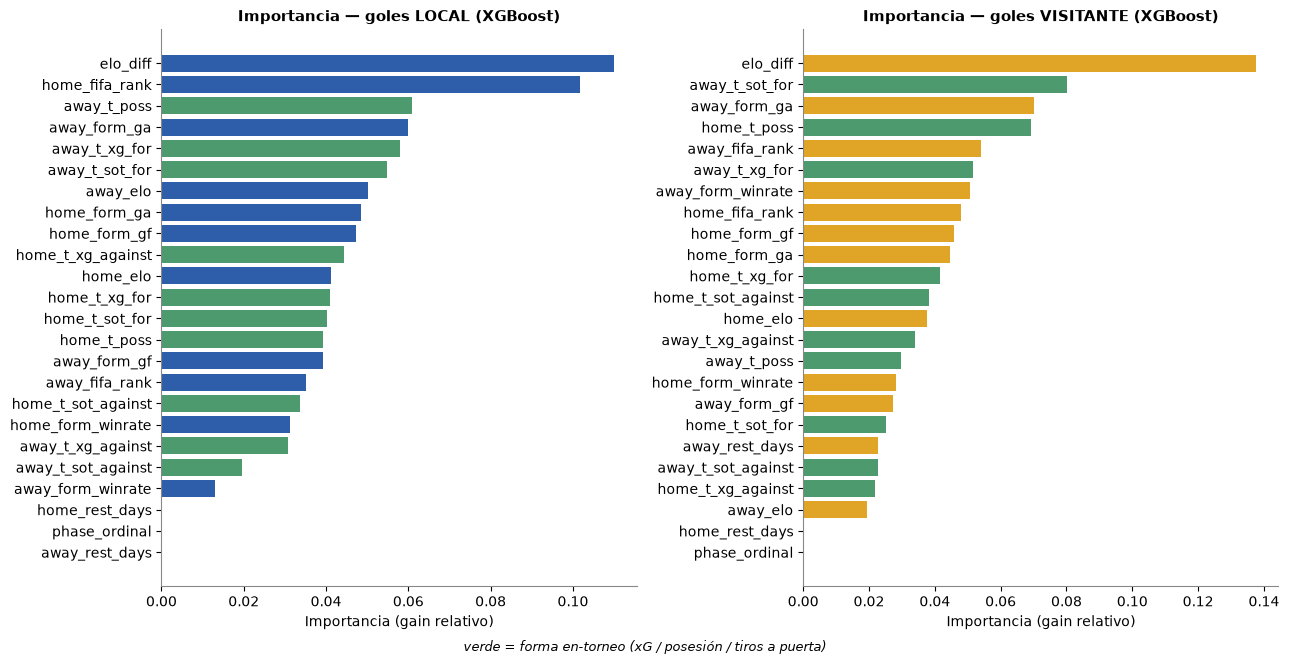

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.size": 10, "axes.edgecolor": "#888888"})

COLOR_HOME, COLOR_DRAW, COLOR_AWAY = "#2E5EAA", "#999999", "#E0A526"

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, model, title, color in [(axes[0], model_home, "goles LOCAL", COLOR_HOME),
                                (axes[1], model_away, "goles VISITANTE", COLOR_AWAY)]:
    imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    bar_colors = ["#4C9A6E" if c in TOURN_COLS else color for c in imp.index]
    ax.barh(imp.index, imp.values, color=bar_colors)
    ax.set_title(f"Importancia — {title} (XGBoost)", fontsize=11, weight="bold")
    ax.set_xlabel("Importancia (gain relativo)")
    ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.01, "verde = forma en-torneo (xG / posesión / tiros a puerta)",
         ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.show()

## 5. `predict_match()` — probabilidades vía Poisson

Con las dos λ (goles esperados) que dan los modelos, se construye la matriz de
probabilidad conjunta de marcador asumiendo que los goles de cada equipo son
Poisson independientes, truncada a `max_goals` y renormalizada. De ahí salen
el 1X2 y los marcadores más probables.

In [6]:
import math

def _poisson_pmf(k, lam):
    return math.exp(-lam) * lam ** k / math.factorial(k)


def predict_match(home_team, away_team, phase, max_goals=7):
    """Predicción de un cruce: λ local y visitante (XGBoost 24f) -> matriz de Poisson."""
    h_str, a_str = team_strength(home_team), team_strength(away_team)
    h_form, a_form = team_pre_wc_form(home_team), team_pre_wc_form(away_team)
    last_played = pd.to_datetime(wc[wc.status == "played"].date).max()
    as_of = last_played + pd.Timedelta(days=1)
    h_rest = team_rest_days(home_team, as_of, wc)
    a_rest = team_rest_days(away_team, as_of, wc)
    h_t = team_tournament_stats(home_team, as_of, wc)
    a_t = team_tournament_stats(away_team, as_of, wc)
    median_rest = pd.concat([features.home_rest_days, features.away_rest_days]).median()
    phase_ord = ROUND_ORDINAL.get(phase, ROUND_ORDINAL["Group stage"])

    row = pd.DataFrame([{
        "home_elo": h_str["elo"], "away_elo": a_str["elo"],
        "elo_diff": h_str["elo"] - a_str["elo"],
        "home_fifa_rank": h_str["fifa_rank"], "away_fifa_rank": a_str["fifa_rank"],
        "home_form_gf": h_form["form_gf"], "home_form_ga": h_form["form_ga"],
        "home_form_winrate": h_form["form_winrate"],
        "away_form_gf": a_form["form_gf"], "away_form_ga": a_form["form_ga"],
        "away_form_winrate": a_form["form_winrate"],
        "home_rest_days": h_rest if h_rest is not None else median_rest,
        "away_rest_days": a_rest if a_rest is not None else median_rest,
        "phase_ordinal": phase_ord,
        **{f"home_{k}": v for k, v in h_t.items()},
        **{f"away_{k}": v for k, v in a_t.items()},
    }])[FEATURE_COLS]

    lam_home = max(float(model_home.predict(row)[0]), 0.05)
    lam_away = max(float(model_away.predict(row)[0]), 0.05)

    probs = pd.DataFrame(
        [[_poisson_pmf(i, lam_home) * _poisson_pmf(j, lam_away) for j in range(max_goals + 1)]
         for i in range(max_goals + 1)])
    probs /= probs.values.sum()  # renormaliza la cola truncada en max_goals

    p_home_win = sum(probs.iloc[i, j] for i in range(max_goals + 1) for j in range(max_goals + 1) if i > j)
    p_draw = sum(probs.iloc[i, i] for i in range(max_goals + 1))
    p_away_win = 1 - p_home_win - p_draw

    scorelines = sorted(
        ((f"{i}-{j}", probs.iloc[i, j]) for i in range(max_goals + 1) for j in range(max_goals + 1)),
        key=lambda x: -x[1])[:5]

    return {
        "home_team": home_team, "away_team": away_team, "phase": phase,
        "lambda_home": lam_home, "lambda_away": lam_away,
        "p_home_win": p_home_win, "p_draw": p_draw, "p_away_win": p_away_win,
        "top_scorelines": scorelines, "prob_matrix": probs,
    }


pending = bracket_state[(bracket_state.confirmed_teams) & (bracket_state.status != "played")]
clean_pending = pending[pending.discrepancy.isna()]
demo = (clean_pending if len(clean_pending) else pending).iloc[0]
r = predict_match(demo.home_team, demo.away_team, demo["round"])
print(f"{r['home_team']} vs {r['away_team']} ({r['phase']}): "
     f"λ={r['lambda_home']:.2f}-{r['lambda_away']:.2f} | "
     f"1={r['p_home_win']:.1%} X={r['p_draw']:.1%} 2={r['p_away_win']:.1%}")

Brazil vs Norway (Round of 16): λ=2.37-0.41 | 1=81.3% X=13.9% 2=4.8%


## 6. Análisis y predicciones — `display_prediction()`

Para un cruce dado, muestra en un solo vistazo: el heatmap de probabilidad de
marcador, la tabla de los 5 marcadores más probables, las barras 1X2 y la
predicción destacada. Colores fijos por rol (no por selección, para que la
lectura sea consistente entre partidos): azul = local, gris = empate,
ámbar = visitante.

In [7]:
def display_prediction(home_team, away_team, phase, actual_result=None):
    """Predicción visual completa de un cruce.

    `actual_result`: tupla opcional (goles_local, goles_visitante) reales,
    para comparar contra la predicción (marca la celda real en el heatmap).
    """
    result = predict_match(home_team, away_team, phase)
    probs = result["prob_matrix"]
    max_goals = probs.shape[0] - 1

    fig = plt.figure(figsize=(11, 7))
    gs = fig.add_gridspec(2, 2, height_ratios=[3, 1.3], width_ratios=[1.3, 1])

    # a) heatmap de marcadores
    ax_hm = fig.add_subplot(gs[0, 0])
    im = ax_hm.imshow(probs.values * 100, cmap="Blues", aspect="auto")
    ax_hm.set_xticks(range(max_goals + 1)); ax_hm.set_yticks(range(max_goals + 1))
    ax_hm.set_xlabel(f"Goles {away_team}"); ax_hm.set_ylabel(f"Goles {home_team}")
    ax_hm.set_title("Probabilidad de marcador (%)", fontsize=11, weight="bold")
    vmax = probs.values.max() * 100
    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            v = probs.values[i, j] * 100
            if v >= 1:
                ax_hm.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                          color="white" if v > vmax * 0.55 else "#333333")
    if actual_result is not None:
        ax_hm.add_patch(plt.Rectangle((actual_result[1] - 0.5, actual_result[0] - 0.5), 1, 1,
                                      fill=False, edgecolor="#1a1a1a", linewidth=2.5))
    fig.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04)

    # c) barras 1X2
    ax_bar = fig.add_subplot(gs[0, 1])
    labels = [f"Gana\n{home_team}", "Empate", f"Gana\n{away_team}"]
    vals = [result["p_home_win"] * 100, result["p_draw"] * 100, result["p_away_win"] * 100]
    bars = ax_bar.barh(labels, vals, color=[COLOR_HOME, COLOR_DRAW, COLOR_AWAY])
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Probabilidad (%)")
    ax_bar.set_title("Resultado 1X2", fontsize=11, weight="bold")
    for b, v in zip(bars, vals):
        ax_bar.text(v + 1.5, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", fontsize=10)
    ax_bar.spines[["top", "right"]].set_visible(False)

    # b) tabla top-5
    ax_tab = fig.add_subplot(gs[1, 0])
    ax_tab.axis("off")
    table_data = [[s, f"{p:.1%}"] for s, p in result["top_scorelines"]]
    tab = ax_tab.table(cellText=table_data, colLabels=["Marcador", "Prob."],
                       loc="center", cellLoc="center")
    tab.auto_set_font_size(False); tab.set_fontsize(10); tab.scale(1, 1.5)
    ax_tab.set_title("Marcadores más probables", fontsize=11, weight="bold", pad=20)

    # d) texto destacado
    ax_txt = fig.add_subplot(gs[1, 1])
    ax_txt.axis("off")
    if result["p_home_win"] > result["p_away_win"]:
        favorite, fav_p = home_team, result["p_home_win"]
    else:
        favorite, fav_p = away_team, result["p_away_win"]
    top_score, top_p = result["top_scorelines"][0]
    txt = f"Favorito: {favorite}\n({fav_p:.0%} de ganar)\n\nMarcador más probable:\n{top_score}  ({top_p:.1%})"
    if actual_result is not None:
        acierto = "✓ acertado" if (actual_result[0], actual_result[1]) == tuple(map(int, top_score.split("-"))) else ""
        txt += f"\n\nResultado real:\n{actual_result[0]}-{actual_result[1]}  {acierto}"
    ax_txt.text(0.5, 0.5, txt, ha="center", va="center", fontsize=12,
               bbox=dict(boxstyle="round,pad=0.6", fc="#F2F2F2", ec="#CCCCCC"))

    fig.suptitle(f"{home_team} vs {away_team} — {phase}", fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()
    return result

### Ejemplo 1 — un partido YA JUGADO (predicción vs realidad)

Para comparar de forma honesta, se calculan las features del partido **con
los datos de forma pre-Mundial y Elo previos al torneo** (las mismas que usó
el entrenamiento) y se compara la predicción contra el marcador real.

Partido ya jugado elegido: Colombia 1.0-0.0 Ghana (Round of 32, 2026-07-03)


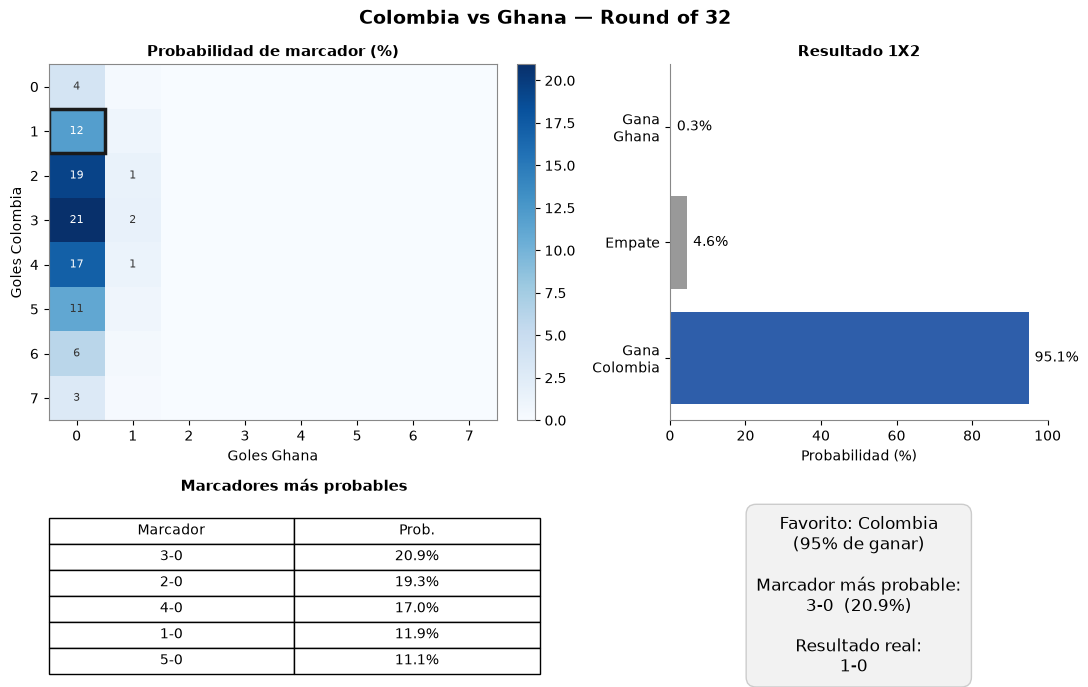

In [8]:
played_sorted = wc[wc.status == "played"].sort_values("date")
last_played_match = played_sorted.iloc[-1]
print(f"Partido ya jugado elegido: {last_played_match.home_team} {last_played_match.home_goals}-"
     f"{last_played_match.away_goals} {last_played_match.away_team} "
     f"({last_played_match['round']}, {last_played_match.date})")

_ = display_prediction(last_played_match.home_team, last_played_match.away_team,
                       last_played_match["round"],
                       actual_result=(int(last_played_match.home_goals), int(last_played_match.away_goals)))

### Ejemplo 2 — un cruce futuro confirmado (`get_bracket_state()`)

Cruce de ejemplo: Partido 91 (Round of 16) Brazil vs Norway — status: scheduled


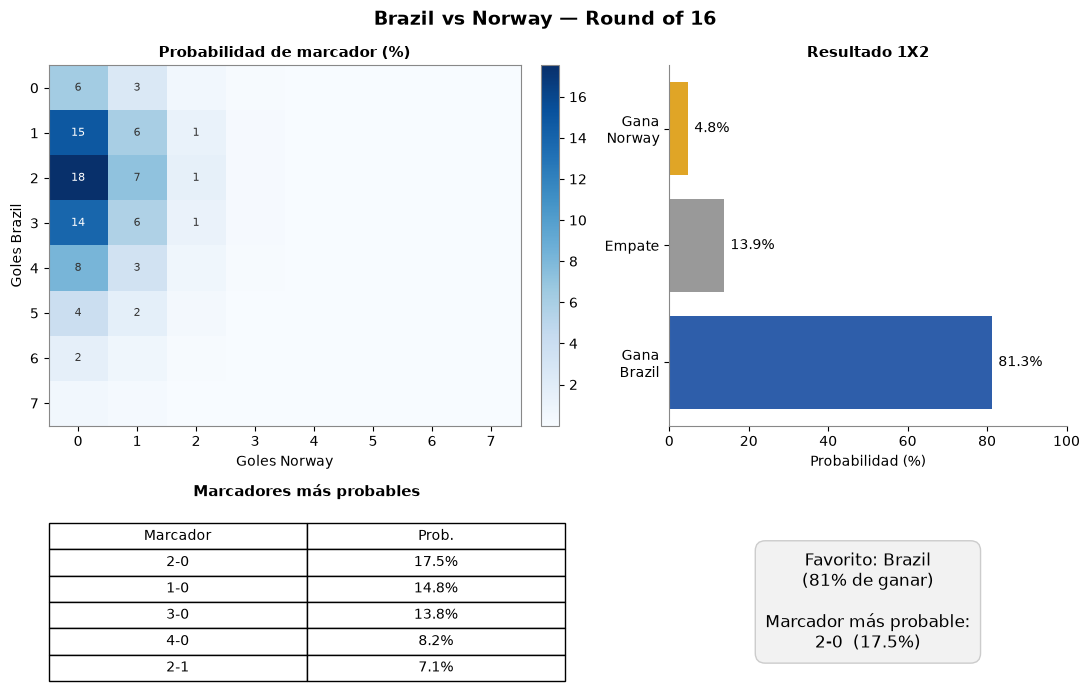

In [9]:
pending_clean = bracket_state[(bracket_state.confirmed_teams) &
                              (bracket_state.status != "played") &
                              (bracket_state.discrepancy.isna())]
demo2 = pending_clean.iloc[0]
print(f"Cruce de ejemplo: Partido {demo2.match_number} ({demo2['round']}) "
     f"{demo2.home_team} vs {demo2.away_team} — status: {demo2.status}")
_ = display_prediction(demo2.home_team, demo2.away_team, demo2["round"])

### Ejemplo 3 — otro cruce condicional (equipo aún por confirmar)

Partido 97 (Quarterfinal): Ganador de Partido 89 (Canada vs Morocco) vs Ganador de Partido 90 (Paraguay vs France)
Todavía condicional -> no se puede predecir con equipos reales; se muestra el siguiente cruce confirmado en su lugar.


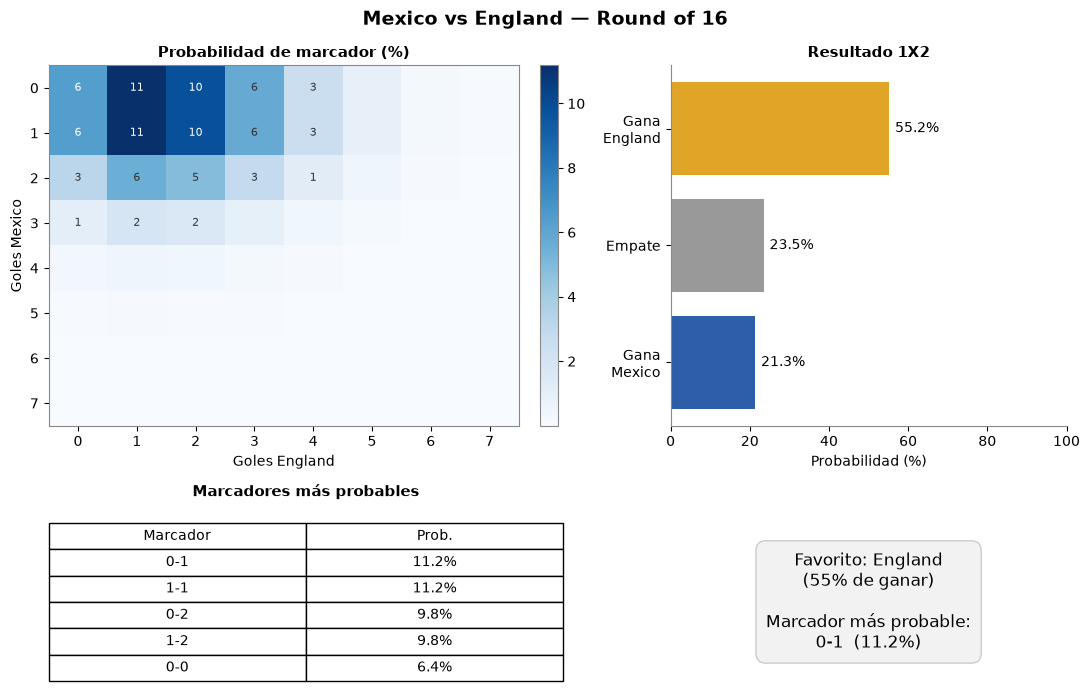

In [10]:
conditional = bracket_state[~bracket_state.confirmed_teams]
if len(conditional):
    demo3 = conditional.iloc[0]
    print(f"Partido {demo3.match_number} ({demo3['round']}): {demo3.home_team} vs {demo3.away_team}")
    print("Todavía condicional -> no se puede predecir con equipos reales; "
         "se muestra el siguiente cruce confirmado en su lugar.")
    demo3b = pending_clean.iloc[1] if len(pending_clean) > 1 else pending_clean.iloc[0]
    _ = display_prediction(demo3b.home_team, demo3b.away_team, demo3b["round"])
else:
    print("No quedan casillas condicionales por ahora.")

## 7. `predict_round()` — la ronda completa de un vistazo

Predice **todos** los partidos de una fase a la vez, en vez de uno a uno.
Para las casillas todavía condicionales (p. ej. "Ganador de Partido 83 vs
Ganador de Partido 84"), no hay dos equipos reales que pasar a `predict_match()`
— así que se resuelve cada casilla al equipo **más probable** según la
predicción de su propio partido decisivo (recursivamente, si hiciera falta
remontarse más de una ronda), y el resultado se marca explícitamente como
**proyección condicional**, no como predicción firme.

In [11]:
PHASE_NAME_MAP = {
    "grupos": "Group stage", "fase de grupos": "Group stage",
    "dieciseisavos": "Round of 32", "treintaidosavos": "Round of 32",
    "octavos": "Round of 16", "octavos de final": "Round of 16",
    "cuartos": "Quarterfinal", "cuartos de final": "Quarterfinal",
    "semis": "Semifinal", "semifinales": "Semifinal",
    "tercer puesto": "Third place", "final": "Final",
}

# índice match_number -> definición del partido en el cuadro (slots de grupo
# para dieciseisavos, o "ganador/perdedor de partido N" para el resto)
MATCH_BY_NUM = {m["match_number"]: m for m in
               bracket_structure["round_of_32"] + bracket_structure["progression"]}

_standings_rt = compute_group_standings(wc)
_thirds_rt = rank_third_place(_standings_rt)
_qualified_thirds_rt = (set(_thirds_rt.head(8).group) if len(_thirds_rt) >= 8
                        else set(bracket_structure["qualified_third_place_groups_2026"]))
_outcome_cache = {}


def _match_outcome(num):
    """Para el partido `num` del cuadro: quién lo disputa, si ya está decidido
    (jugado) y, si no, quién es favorito según predict_match() y con qué probabilidad.
    """
    if num in _outcome_cache:
        return _outcome_cache[num]
    m = MATCH_BY_NUM[num]
    if "home_slot" in m:
        round_name, home_src, away_src = "Round of 32", m["home_slot"], m["away_slot"]
    else:
        round_name, home_src, away_src = m["round"], m["home_source"], m["away_source"]
    home, _, _ = _source_outcome(home_src)
    away, _, _ = _source_outcome(away_src)

    if home is None or away is None:
        outcome = None
    else:
        row = _find_match_row(wc, round_name, home, away)
        if row is not None and row["status"] == "played":
            if row.home_team == home:
                hg, ag, hp, ap = row.home_goals, row.away_goals, row.get("home_pens"), row.get("away_pens")
            else:
                hg, ag, hp, ap = row.away_goals, row.home_goals, row.get("away_pens"), row.get("home_pens")
            home_wins = hg > ag or (hg == ag and pd.notna(hp) and hp > ap)
            winner, loser = (home, away) if home_wins else (away, home)
            outcome = {"home": home, "away": away, "certain": True, "round": round_name,
                      "winner": winner, "loser": loser,
                      "p_home": 1.0 if home_wins else 0.0, "p_away": 0.0 if home_wins else 1.0}
        else:
            pred = predict_match(home, away, round_name)
            winner, loser = (home, away) if pred["p_home_win"] >= pred["p_away_win"] else (away, home)
            outcome = {"home": home, "away": away, "certain": False, "round": round_name,
                      "winner": winner, "loser": loser,
                      "p_home": pred["p_home_win"], "p_away": pred["p_away_win"]}
    _outcome_cache[num] = outcome
    return outcome


def _source_outcome(spec):
    """'1A'/'3D' (slot de grupo, cierto) o 'W73'/'L101' (ganador/perdedor de un
    partido, cierto si ya se jugó, más probable si no) -> (equipo, certeza, prob)."""
    if len(spec) == 2 and spec[0] in "123":
        team = _resolve_slot(spec, _standings_rt, _qualified_thirds_rt)
        return (team, True, 1.0) if team else (None, False, 0.0)
    kind, num = spec[0], int(spec[1:])
    outcome = _match_outcome(num)
    if outcome is None:
        return (None, False, 0.0)
    team = outcome["winner"] if kind == "W" else outcome["loser"]
    prob = outcome["p_home"] if team == outcome["home"] else outcome["p_away"]
    return (team, outcome["certain"], prob)


TIGHT_THRESHOLD = 0.55  # por debajo de esto, la proyección condicional es poco fiable


def predict_round(phase):
    """Predicción compacta de TODOS los partidos de una fase del cuadro.

    `phase`: nombre en español ("dieciseisavos", "octavos", "cuartos", "semis",
    "tercer puesto", "final") o el nombre interno en inglés de `round`.
    """
    round_name = PHASE_NAME_MAP.get(phase.lower().strip(), phase)
    rows_of_round = bracket_state[bracket_state["round"] == round_name].sort_values("match_number")
    if rows_of_round.empty:
        raise ValueError(f"No hay partidos para la fase {phase!r}")

    out = []
    for _, r in rows_of_round.iterrows():
        if r.status == "played":
            out.append({"match_number": r.match_number, "local": r.home_team, "visitante": r.away_team,
                       "marcador_probable": r.result, "prob_marcador": None,
                       "p_local": None, "p_empate": None, "p_visitante": None,
                       "estado": "jugado", "nota": None})
            continue

        nota = None
        if r.confirmed_teams:
            home, away, estado = r.home_team, r.away_team, "confirmado-pendiente"
        else:
            m = MATCH_BY_NUM[r.match_number]
            home_src = m.get("home_slot", m.get("home_source"))
            away_src = m.get("away_slot", m.get("away_source"))
            home, home_cert, home_p = _source_outcome(home_src)
            away, away_cert, away_p = _source_outcome(away_src)
            if home is None or away is None:
                out.append({"match_number": r.match_number, "local": r.home_team, "visitante": r.away_team,
                           "marcador_probable": None, "prob_marcador": None,
                           "p_local": None, "p_empate": None, "p_visitante": None,
                           "estado": "condicional (sin proyección posible aún)", "nota": None})
                continue
            avisos = []
            for team, certain, p in ((home, home_cert, home_p), (away, away_cert, away_p)):
                if not certain:
                    aviso = " ⚠ MUY AJUSTADO, poco fiable" if p < TIGHT_THRESHOLD else ""
                    avisos.append(f"sujeto a que gane {team} ({p:.0%}){aviso}")
            estado, nota = "condicional", "; ".join(avisos)

        pred = predict_match(home, away, round_name)
        top_score, top_p = pred["top_scorelines"][0]
        out.append({
            "match_number": r.match_number,
            "local": home if r.confirmed_teams else f"{home}*",
            "visitante": away if r.confirmed_teams else f"{away}*",
            "marcador_probable": top_score, "prob_marcador": top_p,
            "p_local": pred["p_home_win"], "p_empate": pred["p_draw"], "p_visitante": pred["p_away_win"],
            "estado": estado, "nota": nota,
        })

    df = pd.DataFrame(out)
    n_jugado = (df.estado == "jugado").sum()
    n_confirmado = (df.estado == "confirmado-pendiente").sum()
    n_condicional = df.estado.str.startswith("condicional").sum()
    print(f"{round_name}: {len(df)} partidos  |  jugados: {n_jugado}  |  "
         f"confirmados-pendientes: {n_confirmado}  |  condicionales: {n_condicional}")
    return df


def style_round_table(df):
    """Formato visual: gris = jugado, ámbar+cursiva = proyección condicional
    (para que no se confunda con una predicción firme), blanco = confirmado-pendiente."""
    def row_style(row):
        if row.estado == "jugado":
            return ["background-color: #E8E8E8"] * len(row)
        if row.estado.startswith("condicional"):
            return ["background-color: #FFF3CD; font-style: italic"] * len(row)
        return [""] * len(row)

    fmt = {
        "prob_marcador": lambda v: f"{v:.1%}" if pd.notna(v) else "—",
        "p_local": lambda v: f"{v:.0%}" if pd.notna(v) else "—",
        "p_empate": lambda v: f"{v:.0%}" if pd.notna(v) else "—",
        "p_visitante": lambda v: f"{v:.0%}" if pd.notna(v) else "—",
    }
    return (df.style.apply(row_style, axis=1).format(fmt)
           .set_caption("gris = jugado &nbsp;|&nbsp; blanco = confirmado, pendiente de jugar "
                       "&nbsp;|&nbsp; ámbar cursiva * = proyección condicional (no firme)")
           .hide(axis="index"))

### Ronda actualmente en curso — dieciseisavos (Round of 32)

Mezcla partidos ya jugados (para comparar) con los que quedan por disputarse,
ya con los dos equipos confirmados (la fase de grupos está completa).

In [12]:
tabla_r32 = predict_round("dieciseisavos")
style_round_table(tabla_r32)

Round of 32: 16 partidos  |  jugados: 16  |  confirmados-pendientes: 0  |  condicionales: 0


match_number,local,visitante,marcador_probable,prob_marcador,p_local,p_empate,p_visitante,estado,nota
73,South Africa,Canada,0-1,—,—,—,—,jugado,None
74,Germany,Paraguay,1-1 (pen. 3-4),—,—,—,—,jugado,None
75,Netherlands,Morocco,1-1 (pen. 2-3),—,—,—,—,jugado,None
76,Brazil,Japan,2-1,—,—,—,—,jugado,None
77,France,Sweden,3-0,—,—,—,—,jugado,None
78,Côte d'Ivoire,Norway,1-2,—,—,—,—,jugado,None
79,Mexico,Ecuador,2-0,—,—,—,—,jugado,None
80,England,Congo DR,2-1,—,—,—,—,jugado,None
81,USA,Bosnia and Herzegovina,2-0,—,—,—,—,jugado,None
82,Belgium,Senegal,3-2,—,—,—,—,jugado,None


### Siguiente ronda a completarse — octavos (Round of 16)

Esta es la que de verdad enseña las tres situaciones: partidos con equipos
confirmados, y partidos condicionales cuyos dos cruces previos (dieciseisavos)
todavía no se han jugado — se proyectan con el favorito de cada uno, marcados
con `*` y con la nota explicando de qué resultado dependen.

In [13]:
tabla_r16 = predict_round("octavos")
style_round_table(tabla_r16)

Round of 16: 8 partidos  |  jugados: 0  |  confirmados-pendientes: 8  |  condicionales: 0


match_number,local,visitante,marcador_probable,prob_marcador,p_local,p_empate,p_visitante,estado,nota
89,Canada,Morocco,1-1,10.4%,24%,23%,53%,confirmado-pendiente,None
90,Paraguay,France,0-3,18.4%,1%,5%,94%,confirmado-pendiente,None
91,Brazil,Norway,2-0,17.5%,81%,14%,5%,confirmado-pendiente,None
92,Mexico,England,0-1,11.2%,21%,23%,55%,confirmado-pendiente,None
93,USA,Belgium,1-1,11.8%,28%,25%,48%,confirmado-pendiente,None
94,Portugal,Spain,0-1,24.3%,12%,30%,58%,confirmado-pendiente,None
95,Switzerland,Colombia,0-1,11.1%,21%,23%,56%,confirmado-pendiente,None
96,Argentina,Egypt,2-0,20.7%,83%,13%,3%,confirmado-pendiente,None


## 8. Simulación Monte Carlo — probabilidades de avance por selección

Simula el cuadro completo **N veces** desde el estado actual:

- Partidos ya jugados: el ganador real es fijo en todas las simulaciones.
- Partidos pendientes: se muestrean goles de distribuciones Poisson con las λ
  de `predict_match()`. En caso de empate (eliminatoria), 50 % de probabilidad
  a cada equipo (simula prórroga + penaltis).

El resultado es la fracción de simulaciones en que cada selección llega a
octavos, cuartos, semifinales, final y se proclama campeona.

In [14]:
import numpy as np

_lambda_cache = {}

def _get_lambdas(home, away, round_name):
    """Devuelve (lam_home, lam_away) para un cruce dado, con caché."""
    key = (home, away, round_name)
    if key not in _lambda_cache:
        r = predict_match(home, away, round_name)
        _lambda_cache[key] = (r["lambda_home"], r["lambda_away"])
    return _lambda_cache[key]


def _r32_actual_winner(home, away):
    """Ganador real de un partido de dieciseisavos ya jugado, o None si no jugado."""
    row = _find_match_row(wc, "Round of 32", home, away)
    if row is None or row["status"] != "played":
        return None
    if row.home_team == home:
        hg, ag = row.home_goals, row.away_goals
        hp, ap = row.get("home_pens"), row.get("away_pens")
    else:
        hg, ag = row.away_goals, row.home_goals
        hp, ap = row.get("away_pens"), row.get("home_pens")
    if hg > ag:
        return home
    if ag > hg:
        return away
    if pd.notna(hp) and pd.notna(ap):
        return home if float(hp) > float(ap) else away
    return None


def simulate_tournament(n_sims=10_000, seed=2026):
    """Simula el cuadro completo n_sims veces y devuelve probabilidades de avance."""
    rng_mc = np.random.default_rng(seed)
    all_teams = sorted({t for g in GROUPS.values() for t in g})
    ROUNDS_MC = ["Round of 16", "Quarterfinal", "Semifinal", "Final"]
    MATCH_DEF = {m["match_number"]: m for m in
                 bracket_structure["round_of_32"] + bracket_structure["progression"]}

    # Partidos de dieciseisavos: equipos resueltos por clasificaciones de grupo
    r32_teams = {}
    for m in bracket_structure["round_of_32"]:
        mn = m["match_number"]
        home = _resolve_slot(m["home_slot"], _standings_rt, _qualified_thirds_rt)
        away = _resolve_slot(m["away_slot"], _standings_rt, _qualified_thirds_rt)
        actual_w = _r32_actual_winner(home, away) if home and away else None
        r32_teams[mn] = {"home": home, "away": away, "fixed_winner": actual_w}

    # Agrupar partidos de cada ronda siguiente
    rounds_matches = {r: [m for m in bracket_structure["progression"] if m["round"] == r]
                      for r in ROUNDS_MC}

    reach = {team: {"Round of 16": 0, "Quarterfinal": 0,
                    "Semifinal": 0, "Final": 0, "Champion": 0}
             for team in all_teams}

    for _ in range(n_sims):
        winners = {}

        # -- Dieciseisavos: fijo o muestreado --
        for mn, info in r32_teams.items():
            h, a = info["home"], info["away"]
            if h is None or a is None:
                winners[mn] = None
                continue
            if info["fixed_winner"]:
                winners[mn] = info["fixed_winner"]
            else:
                lam_h, lam_a = _get_lambdas(h, a, "Round of 32")
                hg = rng_mc.poisson(lam_h)
                ag = rng_mc.poisson(lam_a)
                if hg > ag:
                    winners[mn] = h
                elif ag > hg:
                    winners[mn] = a
                else:
                    winners[mn] = h if rng_mc.random() < 0.5 else a

        # -- Octavos, cuartos, semis, final: muestreado --
        def resolve(src):
            kind, num = src[0], int(src[1:])
            return winners.get(num)

        for round_name in ROUNDS_MC:
            for m in rounds_matches[round_name]:
                mn = m["match_number"]
                h = resolve(m["home_source"])
                a = resolve(m["away_source"])
                if h is None or a is None:
                    winners[mn] = None
                    continue
                lam_h, lam_a = _get_lambdas(h, a, round_name)
                hg = rng_mc.poisson(lam_h)
                ag = rng_mc.poisson(lam_a)
                if hg > ag:
                    w = h
                elif ag > hg:
                    w = a
                else:
                    w = h if rng_mc.random() < 0.5 else a
                winners[mn] = w
                reach[h][round_name] += 1
                reach[a][round_name] += 1
                if round_name == "Final":
                    reach[w]["Champion"] += 1

    rows = []
    for team in all_teams:
        r = reach[team]
        rows.append({
            "team": team,
            "p_r16":   r["Round of 16"] / n_sims,
            "p_qf":    r["Quarterfinal"] / n_sims,
            "p_sf":    r["Semifinal"] / n_sims,
            "p_final": r["Final"] / n_sims,
            "p_champ": r["Champion"] / n_sims,
        })
    return pd.DataFrame(rows).sort_values("p_champ", ascending=False).reset_index(drop=True)


print("Función simulate_tournament() definida.")

Función simulate_tournament() definida.


In [15]:
import time

t0 = time.time()
mc_df = simulate_tournament(n_sims=10_000, seed=2026)
elapsed = time.time() - t0
mc_df.to_csv(DATA_DIR / "monte_carlo_probs.csv", index=False)
print(f"10 000 simulaciones completadas en {elapsed:.1f}s | guardado en data/monte_carlo_probs.csv")
print()

# -- Tabla completa: top 16 por prob. campeon --
def style_mc_table(df, n=16):
    sub = df.head(n).copy()
    pct_cols = ["p_r16", "p_qf", "p_sf", "p_final", "p_champ"]
    for c in pct_cols:
        sub[c] = sub[c].map("{:.1%}".format)
    sub.columns = ["Seleccion", "R16", "Cuartos", "Semis", "Final", "Campeon"]
    sub.index = range(1, len(sub) + 1)
    return sub.style.set_caption(
        "Monte Carlo 10 000 simulaciones | estado del cuadro: " +
        str(pd.Timestamp.now().date())
    )

style_mc_table(mc_df)

10 000 simulaciones completadas en 5.0s | guardado en data/monte_carlo_probs.csv



,Seleccion,R16,Cuartos,Semis,Final,Campeon
1,Argentina,100.0%,90.4%,57.9%,35.2%,22.2%
2,France,100.0%,96.4%,63.9%,39.2%,21.2%
3,Spain,100.0%,72.9%,48.6%,33.4%,17.6%
4,Brazil,100.0%,88.7%,52.5%,22.7%,11.7%
5,England,100.0%,66.1%,34.3%,17.9%,8.0%
6,Colombia,100.0%,67.6%,32.2%,13.1%,5.5%
7,Morocco,100.0%,63.8%,26.2%,12.6%,5.3%
8,Portugal,100.0%,27.1%,17.6%,6.0%,2.7%
9,Belgium,100.0%,59.4%,18.7%,5.5%,2.5%
10,Mexico,100.0%,33.9%,11.3%,4.0%,1.2%
